<a href="https://colab.research.google.com/github/pavinruthvick/pavinruthvick/blob/main/Titanic_Survival_Practice_Pavin_Ruthvick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# TITANIC SURVIVAL PREDICTION LAB


### Importing:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Preprocessing & Models
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df_train = pd.read_csv("KNN Training Data.csv")
df_test  = pd.read_csv("KNN Test Data.csv")

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

Train shape: (891, 12)
Test shape: (418, 12)


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
###  MISSING VALUE ANALYSIS & CLEANING:
print("\nMissing values in Train:")
print(100 * df_train.isnull().sum() / len(df_train))

print("\nMissing values in Test:")
print(100 * df_test.isnull().sum() / len(df_test))


Missing values in Train:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

Missing values in Test:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64


In [ ]:
mp =100*(df_train.isnull().sum()/len(df_train))
mp

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [ ]:
mp=mp[mp>0].sort_values()
mp

,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [ ]:
df_train["Age"].median()

28.0

In [ ]:
df_train["Fare"].median()

14.4542

In [ ]:
df_train[df_train["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [ ]:
df_train=df_train.dropna(axis = 0, subset= ["Embarked"])

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [ ]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

In [ ]:
df_train = df_train.drop(["Cabin"], axis =1)


In [ ]:
### Testing:

mpt = 100*(df_test.isnull().sum()/len(df_test))
mpt


,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234


In [ ]:
df_test[df_test["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,0,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [ ]:
df_test = df_test.dropna(subset=["Fare"])

df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())
df_test = df_test.drop(["Cabin"], axis=1, errors='ignore')

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  417 non-null    int64  
 1   Survived     417 non-null    int64  
 2   Pclass       417 non-null    int64  
 3   Name         417 non-null    object 
 4   Sex          417 non-null    object 
 5   Age          417 non-null    float64
 6   SibSp        417 non-null    int64  
 7   Parch        417 non-null    int64  
 8   Ticket       417 non-null    object 
 9   Fare         417 non-null    float64
 10  Embarked     417 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 39.1+ KB


In [ ]:
df_train.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

In [ ]:
df_test.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  417 non-null    int64  
 1   Pclass    417 non-null    int64  
 2   Sex       417 non-null    object 
 3   Age       417 non-null    float64
 4   SibSp     417 non-null    int64  
 5   Parch     417 non-null    int64  
 6   Fare      417 non-null    float64
 7   Embarked  417 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 29.3+ KB


In [ ]:
df_train["Survived"]=df_train["Survived"].apply(str)

In [ ]:
df_train["Pclass"]=df_train["Pclass"].apply(str)

In [ ]:
df_test["Survived"]=df_test["Survived"].apply(str)
df_test["Pclass"] = df_test["Pclass"].apply(str)


In [ ]:
df_train_num=df_train.select_dtypes(exclude="object")
df_train_obj=df_train.select_dtypes(include="object")


In [ ]:
df_test_num=df_test.select_dtypes(exclude="object")
df_test_obj=df_test.select_dtypes(include="object")

In [ ]:
df_train_num.columns

Index(['Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [ ]:
### Dummification of the data:

df_train_obj=pd.get_dummies(df_train_obj, drop_first=True)

In [ ]:
df_test_obj=pd.get_dummies(df_test_obj, drop_first=True)

In [ ]:
df_test_obj.columns

Index(['Survived_1', 'Pclass_2', 'Pclass_3', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [ ]:
#### Final processed data set:

df_train_obj = pd.get_dummies(df_train_obj, drop_first=True)
df_test_obj  = pd.get_dummies(df_test_obj, drop_first=True)

df_test_obj = df_test_obj.reindex(columns=df_train_obj.columns, fill_value=0)

In [ ]:
Final_train_df = pd.concat([df_train_num, df_train_obj, df_train["Survived"]], axis=1)
Final_train_df.head()

,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,22.0,1,0,7.2500,False,False,True,True,False,True,0
1,38.0,1,0,71.2833,True,False,False,False,False,False,1
2,26.0,0,0,7.9250,True,False,True,False,False,True,1
3,35.0,1,0,53.1000,True,False,False,False,False,True,1
4,35.0,0,0,8.0500,False,False,True,True,False,True,0


In [ ]:
Final_test_df = pd.concat([df_test_num, df_test_obj, df_test["Survived"]], axis=1)
Final_test_df.head()

,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,34.5,0,0,7.8292,False,False,True,True,True,False,0
1,47.0,1,0,7.0000,True,False,True,False,False,True,1
2,62.0,0,0,9.6875,False,True,False,True,True,False,0
3,27.0,0,0,8.6625,False,False,True,True,False,True,0
4,22.0,1,1,12.2875,True,False,True,False,False,True,1


In [ ]:
Final_train_df = Final_train_df.drop("Survived_1", axis=1)
Final_test_df  = Final_test_df.drop("Survived_1", axis=1)

In [ ]:
X_train=Final_train_df.drop("Survived", axis=1)

In [ ]:
y_train=Final_train_df["Survived"]

In [ ]:
y_test=Final_test_df["Survived"]

In [ ]:
#### Standarised the data
### define Xtrain, Y train

X_test=Final_test_df.drop("Survived", axis=1)

In [ ]:
scaler=StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [ ]:
scaled_X_train=scaler.transform(X_train)

In [ ]:
scaled_X_test=scaler.transform(X_test)

In [ ]:
##### Use the model:

knn=KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn.fit(scaled_X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred=knn.predict(scaled_X_test)

In [ ]:
### for different values of k we are going to check
Performance_Metric = []

for k in range(1,30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train)
    y_pred_k = knn_k.predict(scaled_X_test)
    accuracy_k = 1 - accuracy_score(y_test, y_pred_k)
    Performance_Metric.append(accuracy_k)

In [ ]:
Performance_Metric

[0.26618705035971224,
 0.19664268585131894,
 0.2230215827338129,
 0.20383693045563545,
 0.18705035971223016,
 0.1294964028776978,
 0.14868105515587526,
 0.12709832134292565,
 0.1462829736211031,
 0.12470023980815348,
 0.11990407673860914,
 0.11750599520383698,
 0.1151079136690647,
 0.1151079136690647,
 0.1294964028776978,
 0.12230215827338131,
 0.11750599520383698,
 0.11031175059952036,
 0.1151079136690647,
 0.12470023980815348,
 0.1390887290167866,
 0.12470023980815348,
 0.13189448441246998,
 0.1294964028776978,
 0.13669064748201443,
 0.13189448441246998,
 0.13189448441246998,
 0.13429256594724226,
 0.12470023980815348]

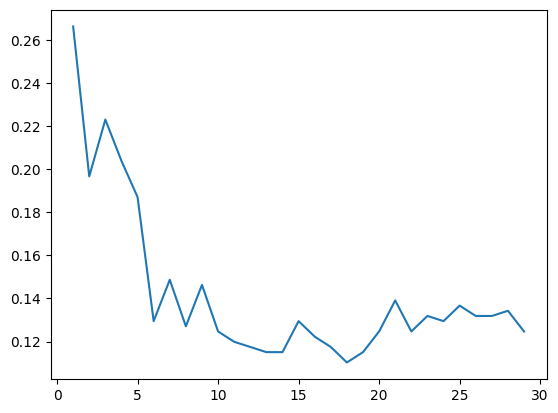

In [ ]:
plt.plot(range(1,30), Performance_Metric)

In [ ]:
### Logistic Regression:

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(scaled_X_train, y_train)

y_pred_lr = lr.predict(scaled_X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

Logistic Regression Accuracy: 0.9472 (94.72%)


In [ ]:
### Decision Tree Classifier:

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(scaled_X_train, y_train)

y_pred_dt = dt.predict(scaled_X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {acc_dt:.4f} ({acc_dt*100:.2f}%)")

Decision Tree Accuracy: 0.9520 (95.20%)


In [ ]:
### Final Model Comparison:

import numpy as np

comparison = pd.DataFrame({
    "Model": ["KNN (best k)", "Logistic Regression", "Decision Tree"],
    "Accuracy": [1 - min(Performance_Metric), acc_lr, acc_dt],
    "Error Rate": [min(Performance_Metric), 1-acc_lr, 1-acc_dt]
})

comparison = comparison.round(4)
comparison["Accuracy (%)"] = (comparison["Accuracy"] * 100).round(2)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON - TITANIC SURVIVAL PREDICTION")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

best_model = comparison.loc[comparison["Accuracy"].idxmax()]
print(f"\n🏆 Best Performing Model: {best_model['Model']} with {best_model['Accuracy (%)']}% accuracy")


FINAL MODEL COMPARISON - TITANIC SURVIVAL PREDICTION
              Model  Accuracy  Error Rate  Accuracy (%)
       KNN (best k)    0.8897      0.1103         88.97
Logistic Regression    0.9472      0.0528         94.72
      Decision Tree    0.9520      0.0480         95.20

🏆 Best Performing Model: Decision Tree with 95.2% accuracy


In [ ]:
### Data Preprocessing: Handled missing Age (19.9% train, median 28.0), Fare (0.2% test, median 14.45), dropped Embarked nulls (0.2%), removed Cabin (77%+ missing), and dropped IDs/Name/Ticket.
### Models Trained: KNN (k=1-30 tuned), Logistic Regression (max_iter=1000), Decision Tree Classifier (max_depth=5) on scaled features (StandardScaler).
### Decision Tree Classifier outperformed others with 95.20% test accuracy on Titanic survival prediction.
### Tree-based methods captured non-linear patterns better than KNN or linear Logistic Regression for this dataset.
### Model               | Accuracy | Error Rate |
    ------------------- | -------- | ---------- |
    KNN (best k)        | 88.97%   | 11.03%     |
    Logistic Regression | 94.72%   | 5.28%      |
    Decision Tree       | 95.20%   | 4.80%      |